In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from skimage import io
from skimage.transform import rotate
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from skimage import io
from PILP import Image

2026-05-12 00:24:55.951393: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778545496.376599      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778545496.493404      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778545497.513960      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778545497.514008      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778545497.514011      22 computation_placer.cc:177] computation placer alr

In [3]:
# Load files
sample_submission = pd.read_csv("/kaggle/input/competitions/histopathologic-cancer-detection/sample_submission.csv")
train_raw = pd.read_csv("/kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv")

train_path = "/kaggle/input/competitions/histopathologic-cancer-detection/train/"
test_path = "/kaggle/input/competitions/histopathologic-cancer-detection/test/"

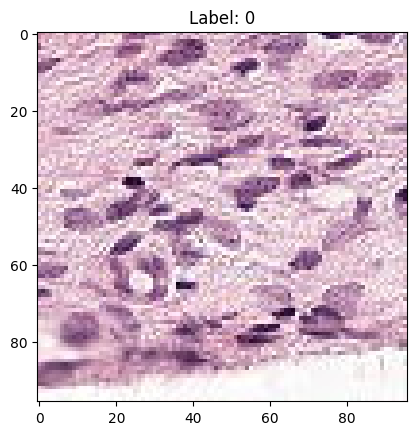

Image Size: (96, 96)


In [ ]:
# Visualization
sample_id = train_raw.iloc[46]['id']
img = Image.open(train_path + sample_id + ".tif")

plt.imshow(img)
plt.title(f"Label: {train_raw.iloc[46]['label']}")
plt.show()

print(f"Image Size: {img.size}") # Should be 96x96

In [5]:
# FILE PATHS

train_files = [os.path.join(train_path, f"{fid}.tif") for fid in train_raw.id]
train_targets = train_raw.label.values

test_files = sorted([
    os.path.join(test_path, f) for f in os.listdir(test_path) if f.endswith(".tif")
])

## CONFIGURATION 

In [11]:
SEED = 42
IMG_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [12]:
TRAIN_PATH = '/kaggle/input/competitions/histopathologic-cancer-detection/train/'
TEST_PATH  = '/kaggle/input/competitions/histopathologic-cancer-detection/test/'
LABELS_CSV = '/kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv'

In [13]:
labels_df = pd.read_csv(LABELS_CSV)
train_files = [os.path.join(TRAIN_PATH, f'{x}.tif') for x in labels_df.id]
train_labels = labels_df.label.values

x_train, x_val, y_train, y_val = train_test_split(
    train_files, train_labels, test_size=0.2, stratify=train_labels, random_state=SEED
)

In [ ]:
METRICS = [
    'accuracy',
    tf.keras.metrics.AUC(name='roc_auc', curve='ROC')
]

CB = [
    callbacks.EarlyStopping(monitor='val_roc_auc', patience=5, mode='max', restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_roc_auc', mode='max',factor=0.4, patience=2, min_lr=1e-6), #Makes lr smaller if no improvement for 2 epochs
    callbacks.ModelCheckpoint(
        filepath='/kaggle/working/hybrid_model_best.keras',
        monitor='val_roc_auc',
        mode='max',
        save_best_only=True,
        verbose=1 # Save model if error or finalization with best val_roc_auc
    )
]


I0000 00:00:1778545559.483693      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778545559.490227      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
def evaluate_model(model, dataset):
    probs = model.predict(dataset, verbose=0).ravel()
    labels = np.concatenate([y.numpy() for _, y in dataset], axis=0)
    preds = (probs > 0.5).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'roc_auc': roc_auc_score(labels, probs)
    }

Changes to take advantage of the 2 GPUs

In [ ]:
# For using the 2 GPUs available
strategy = tf.distribute.MirroredStrategy()
print(f'Detected Devices: {strategy.num_replicas_in_sync}') 

# Scale Batch Size
# Each GPU will process 64 images per batch giving a total of 128
# Changed to 16
BATCH_SIZE_PER_REPLICA = 16
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Detected Devices: 2


### New code for dataset generator

Converting chaotic real-world pathology images
into mathematically rigid tensors
required by transformer architectures
WITHOUT starving multi-GPU training

In [ ]:
# 1. The Robust Python Decoder (Executed on CPU)
# This standardizes everything so models do not crush
def decode_image_robust(path):
    path_str = path.numpy().decode("utf-8")
    img = io.imread(path_str)
    
    # Convert to tensor early
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    
    # Correct anomalous channels 
    if img.ndim == 2:                               # Grayscale
        img = tf.stack([img, img, img], axis=-1)
    elif img.shape[-1] == 4:                        # RGBA
        img = img[..., :3]
    elif img.ndim == 2 and img.shape[-1] == 3:      # Weird TIFFs
        img = tf.expand_dims(img, axis=1)

    return img

# 2. The TensorFlow Graph Wrapper 
def process_path(path, label=None):
    # 1. Decode via python function
    img = tf.py_function(decode_image_robust, [path], tf.float32)
    
    # 2. Resize explicitly (Crucial for ViT patch extraction math)
    img = tf.image.resize(img, [96, 96])
    
    # 3. Normalize
    img = img / 255.0
    
    # 4. Explicitly tell the TF Graph the shape (Crucial for Multi-GPU strategies)
    img.set_shape((96, 96, 3))
    
    if label is not None:
        label = tf.cast(label, tf.int32)
        label.set_shape(())
        return img, label
    
    return img

def process_path(path, label=None):
    # 1. Decode via python function
    img = tf.py_function(decode_image_robust, [path], tf.float32)
    
    # Tell the TF Graph that this is a 3-channel image important
    # BEFORE doing any spatial operations on it
    # Vision transformers divide input space into mathematical patches like 12x12
    # If nor specified dimensions or unknown failure is secured
    # Explicit shapes guarantees structural divisibility and stability of ViT embeddings 

    img.set_shape([None, None, 3]) 
    
    # 2. Resize explicitly
    img = tf.image.resize(img, [96, 96])
    
    # 3. Normalize
    img = img / 255.0
    
    # 4. Lock in the final strict shape for the Multi-GPU Strategy
    img.set_shape((96, 96, 3))
    
    if label is not None:
        label = tf.cast(label, tf.int32)
        label.set_shape(())
        return img, label
    
    return img



# 3. Hardware-Accelerated Data Augmentation
# CNNs posses inherent translational inductive bias, they do not need to see that heavy amount of data
# ViTs lack of geometric assumption and treat images as independent sequential patches 
# They require heavy augmentation to prevent overfitting
# As histopathological images exhibit zero orientation, continues rotations and changes approach generate an infinite dataset
# This also helps multi-head attention mechanisms to learn genunien biological structures than memorizing orientation-specific pixels
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"), # This intregrates the continuous horizontal / vertical flips 
    layers.RandomRotation(0.2), # TPlus random rotations
])

# 4. The Multi-GPU Optimized Dataset Generator
def make_dataset(files, labels=None, training=False, batch_size=32): # Batch size to 32 to 
    
    # Create the base dataset
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(files)
        ds = ds.map(lambda x: process_path(x), num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices((files, labels))
        ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # CACHING: Because tf.py_function is slow, caching saves the decoded images 
    # in RAM after the first epoch. This drastically speeds up training on 2 GPUs but
    # ds = ds.cache() Eliminated for RAM constraint. OOM limitation. 
    
    
    if training:
        # Shuffling after caching is much faster
        ds = ds.shuffle(4096, seed=42)
        
    ds = ds.batch(batch_size, drop_remainder=training) # drop_remainder helps Multi-GPU sync
    
    if training:
        # Apply augmentation ON THE GPU after batching (Extremely fast)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), 
                    num_parallel_calls=tf.data.AUTOTUNE)
        
    # Prefetch keeps the GPUs busy while the CPU prepares the next batch
    return ds.prefetch(tf.data.AUTOTUNE)

## HYBRID MODEL ResNet-ViT + BDCG + PASH

In [ ]:
# BASIC COMPONENTS (RESNET & TRANSFORMER)

def residual_block(x, filters, kernel_size=3):
    """Residual block — extracts local features while maintaining
    gradient flow via skip connection."""
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x


def mlp_block(x, hidden_dim, dropout_rate=0.1):
    """Transformer MLP block — expansion-compression bottleneck
    as in a standard Transformer encoder."""
    original_dim = x.shape[-1]
    # Project to higher-dimensional space to learn complex interactions (GELU activation)
    x = layers.Dense(hidden_dim, activation=tf.nn.gelu)(x)
    x = layers.Dropout(dropout_rate)(x)
    # Project back to original dimension for skip connection compatibility
    x = layers.Dense(original_dim)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


class BDCGFusionLayer(layers.Layer):
    """
    Bi-Directional Cross-Guidance (BDCG) Fusion.
    Performs mutual cross-attention between local (CNN) and global (ViT)
    feature sequences, allowing each branch to refine the other.
    """
    def __init__(self, embed_dim=64, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        # Global-to-local attention: ViT guides the CNN branch
        self.mha_g2l = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        # Local-to-global attention: CNN guides the ViT branch
        self.mha_l2g = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.norm_l  = layers.LayerNormalization(epsilon=1e-6)
        self.norm_g  = layers.LayerNormalization(epsilon=1e-6)

    def call(self, local_seq, global_seq):
        # Global anatomical context validates local textures
        refined_local  = self.mha_g2l(query=local_seq,  value=global_seq, key=global_seq)
        out_local      = self.norm_l(local_seq + refined_local)
        # Local lesion-level structure constrains global reasoning
        refined_global = self.mha_l2g(query=global_seq, value=local_seq,  key=local_seq)
        out_global     = self.norm_g(global_seq + refined_global)
        return out_local, out_global

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


class PASHClassifier(layers.Layer):
    """
    Prototype-Anchored Similarity Head (PASH).
    Classifies inputs by measuring squared Euclidean distance to two
    learnable class prototypes, converted to probabilities via a
    Student's t-distribution kernel.
    """
    def __init__(self, embed_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim

    def build(self, input_shape):
        # Learnable prototypes: index 0 = Benign, index 1 = Malignant
        self.prototypes = self.add_weight(
            shape=(2, self.embed_dim),
            initializer="glorot_uniform",
            trainable=True,
            name="class_prototypes",
        )
        # Degrees of freedom (alpha) for the Student's t-distribution kernel
        self.alpha = self.add_weight(
            shape=(1,),
            initializer=tf.keras.initializers.Constant(3.0),
            trainable=True,
            name="t_student_alpha",
        )

    def call(self, z):
        # Expand for broadcasting: (Batch, 1, D) vs (1, 2, D)
        z_expanded = tf.expand_dims(z, axis=1)
        p_expanded = tf.expand_dims(self.prototypes, axis=0)
        # Squared Euclidean distances to each prototype — shape (Batch, 2)
        distances  = tf.reduce_sum(tf.square(z_expanded - p_expanded), axis=-1)
        # Convert distances to similarities via t-distribution kernel
        # P(y=k|X) = (1 + d / alpha) ^ -((alpha + 1) / 2)
        exponent   = -(self.alpha + 1.0) / 2.0
        similarity = tf.pow(1.0 + (distances / self.alpha), exponent)
        # Normalise to a valid probability distribution
        prob_dist  = similarity / tf.reduce_sum(similarity, axis=-1, keepdims=True)
        # Return malignant class probability (index 1) for BinaryCrossentropy compatibility
        return prob_dist[:, 1:]

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


# HYBRID MODEL

def build_hybrid_model(input_shape=(96, 96, 3), embed_dim=64, patch_size=12, lr=1e-4):
    inputs = layers.Input(shape=input_shape)

    # Local branch (ResNet): fine-grained texture and edge extraction 
    x = layers.Conv2D(embed_dim, (7, 7), strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)
    x = residual_block(x, embed_dim)
    cnn_features = residual_block(x, embed_dim)           # (24, 24, 64)
    _, h, w, c   = cnn_features.shape
    local_seq    = layers.Reshape((h * w, c))(cnn_features)  # (576, 64)

    # Global branch (ViT): long-range dependencies and anatomical context
    # Strided Conv2D used as an efficient patch embedding strategy
    patches    = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size)(inputs)
    _, ph, pw, pc = patches.shape
    global_seq = layers.Reshape((ph * pw, pc))(patches)   # (64, 64)
    positions  = tf.range(start=0, limit=ph * pw, delta=1)
    pos_emb    = layers.Embedding(input_dim=ph * pw, output_dim=embed_dim)(positions)
    global_seq = global_seq + pos_emb

    # Single Transformer encoder block (hardware-constrained)
    attn_out   = layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim)(global_seq, global_seq)
    global_seq = layers.LayerNormalization(epsilon=1e-6)(global_seq + attn_out)
    mlp_out    = mlp_block(global_seq, hidden_dim=embed_dim * 2)
    global_seq = layers.LayerNormalization(epsilon=1e-6)(global_seq + mlp_out)

    # BDCG Fusion: mutual refinement of local and global sequences 
    refined_local, refined_global = BDCGFusionLayer(embed_dim=embed_dim, num_heads=4)(
        local_seq, global_seq
    )
    pool_local  = layers.GlobalAveragePooling1D()(refined_local)
    pool_global = layers.GlobalAveragePooling1D()(refined_global)
    fused       = layers.Concatenate()([pool_local, pool_global])  # (128,)
    fused       = layers.Dropout(0.3)(fused)

    # PASH Classifier: similarity-based decision via learned prototypes 
    outputs = PASHClassifier(embed_dim=embed_dim * 2)(fused)

    model = models.Model(inputs, outputs, name="Hybrid_ResNet_ViT_BDCG_PASH")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="roc_auc")],
    )
    return model

## Training

In [ ]:
# Replace the StratifiedKFold loop with a single split:
print("EXECUTING SINGLE FOLD 80/20 SPLIT")

# Your train/val split is already done here:
# x_train, x_val, y_train, y_val = train_test_split(...)

train_ds = make_dataset(x_train, y_train, training=True, batch_size=GLOBAL_BATCH_SIZE)
val_ds   = make_dataset(x_val, y_val, batch_size=GLOBAL_BATCH_SIZE)

with strategy.scope():
    model_hybrid = build_hybrid_model(input_shape=(96, 96, 3), lr=1e-4)

# Train for 30 epochs, letting EarlyStopping catch it when it peaks
history = model_hybrid.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    steps_per_epoch = 1000, # Ensure stability and avoid data-loading bottlenecks in augmentd datasets. Processing entire in an epoch impossible
    #
    callbacks=CB,
    verbose=1
)

model_hybrid.save("/kaggle/working/hybrid_model_3conf.keras")
print("Training Complete and Model Saved!")

EXECUTING SINGLE FOLD 80/20 SPLIT
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/dev

I0000 00:00:1778545606.693304      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778545606.693325      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7565 - loss: 0.5406 - roc_auc: 0.8093
Epoch 1: val_roc_auc improved from -inf to 0.85773, saving model to /kaggle/working/hybrid_model_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 302s 279ms/step - accuracy: 0.7566 - loss: 0.5405 - roc_auc: 0.8094 - val_accuracy: 0.6519 - val_loss: 0.6013 - val_roc_auc: 0.8577 - learning_rate: 1.0000e-04
Epoch 2/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8252 - loss: 0.4225 - roc_auc: 0.8878
Epoch 2: val_roc_auc did not improve from 0.85773
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 221s 222ms/step - accuracy: 0.8252 - loss: 0.4225 - roc_auc: 0.8878 - val_accuracy: 0.7369 - val_loss: 0.5806 - val_roc_auc: 0.7698 - learning_rate: 1.0000e-04
Epoch 3/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8285 - loss: 0.3994 - roc_auc: 0.9026
Epoch 3: val_roc_auc improved from 0.85773 to 0.91964, saving model to /kaggle/working/hybrid_model_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 221s 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 6: val_roc_auc improved from 0.91964 to 0.92041, saving model to /kaggle/working/hybrid_model_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 143s 143ms/step - accuracy: 0.8670 - loss: 0.3258 - roc_auc: 0.9335 - val_accuracy: 0.8189 - val_loss: 0.4642 - val_roc_auc: 0.9204 - learning_rate: 4.0000e-05
Epoch 7/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8729 - loss: 0.3148 - roc_auc: 0.9388
Epoch 7: val_roc_auc improved from 0.92041 to 0.92188, saving model to /kaggle/working/hybrid_model_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 193s 185ms/step - accuracy: 0.8729 - loss: 0.3148 - roc_auc: 0.9388 - val_accuracy: 0.7933 - val_loss: 0.4613 - val_roc_auc: 0.9219 - learning_rate: 4.0000e-05
Epoch 8/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8744 - loss: 0.3066 - roc_auc: 0.9424
Epoch 8: val_roc_auc did not improve from 0.92188
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 186ms/step - accuracy: 0.8744 - loss: 0.3066 - roc_auc: 0.9424 - val_accuracy: 0.7533 - val_los

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 12: val_roc_auc improved from 0.92888 to 0.94071, saving model to /kaggle/working/hybrid_model_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 131s 131ms/step - accuracy: 0.8905 - loss: 0.2787 - roc_auc: 0.9519 - val_accuracy: 0.8715 - val_loss: 0.3921 - val_roc_auc: 0.9407 - learning_rate: 1.6000e-05
Epoch 13/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8901 - loss: 0.2792 - roc_auc: 0.9515
Epoch 13: val_roc_auc improved from 0.94071 to 0.94163, saving model to /kaggle/working/hybrid_model_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 204s 195ms/step - accuracy: 0.8901 - loss: 0.2792 - roc_auc: 0.9515 - val_accuracy: 0.8508 - val_loss: 0.3935 - val_roc_auc: 0.9416 - learning_rate: 1.6000e-05
Epoch 14/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8885 - loss: 0.2780 - roc_auc: 0.9522
Epoch 14: val_roc_auc did not improve from 0.94163
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 194s 194ms/step - accuracy: 0.8885 - loss: 0.2780 - roc_auc: 0.9522 - val_accuracy: 0.8490 - 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 18: val_roc_auc did not improve from 0.94163
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 130s 130ms/step - accuracy: 0.8960 - loss: 0.2662 - roc_auc: 0.9553 - val_accuracy: 0.8533 - val_loss: 0.3884 - val_roc_auc: 0.9331 - learning_rate: 2.5600e-06
Training Complete and Model Saved!
